/var/folders/33/fw5wlwpj4b78_xvtgsm72q6r0000gq/T/ipykernel_64061/1508390646.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


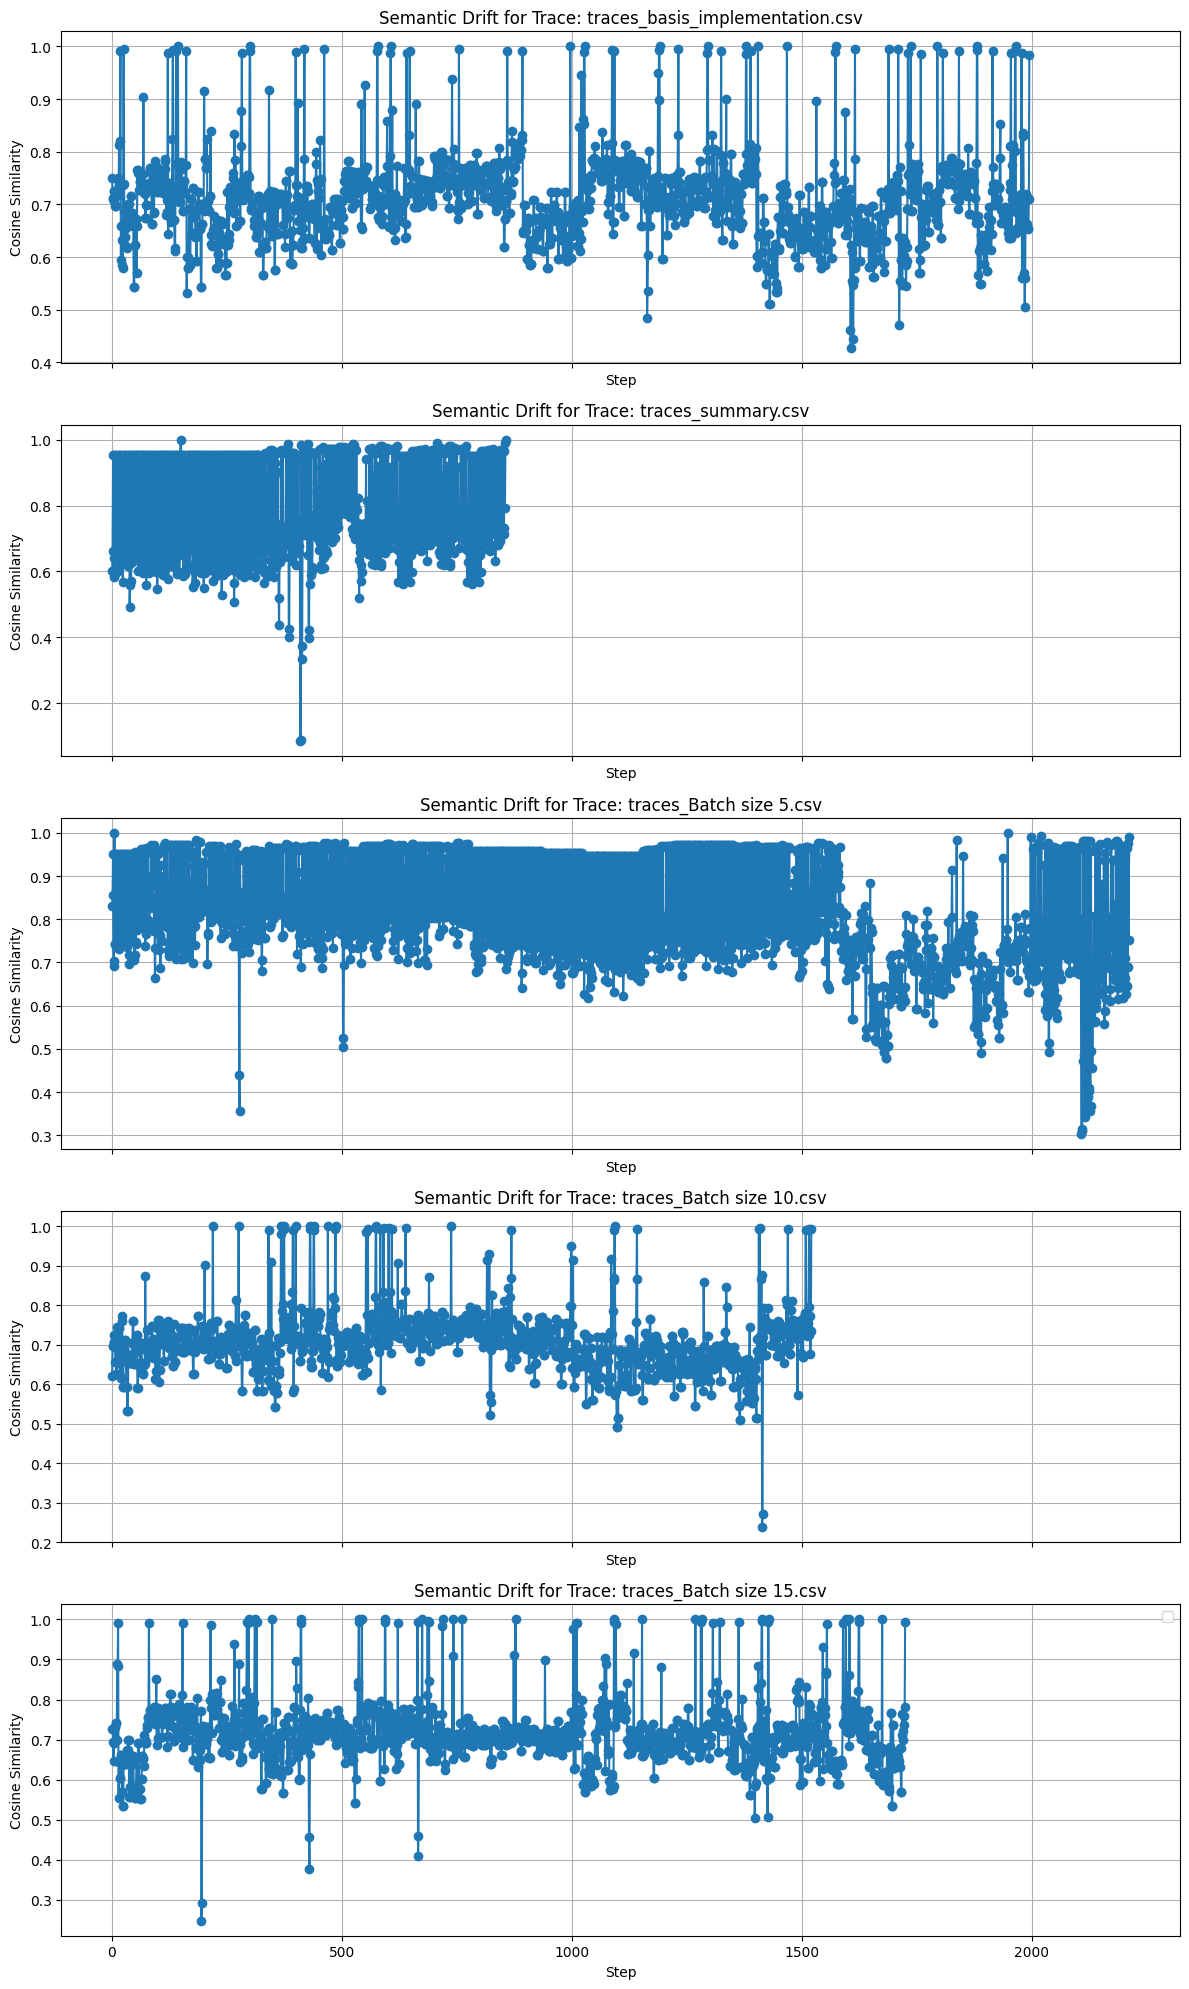

In [48]:
import pandas as pd 
import numpy as np
import os 
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from matplotlib import pyplot as plt



class SemanticDriftAnalysis:
    def __init__(self, path:str,list_traces:list, embed_model:str):
        self.path = path
        self.list_traces = list_traces
        self.embed_model = SentenceTransformer(embed_model)

    def calculate_similarity(self, df_trace):
        # Convert embeddings to numpy array for easier manipulation
        embeddings = np.array(df_trace["embedding"].tolist())
        # Calculate cosine similarity between consecutive rows
        similarities = []
        for i in range(1, len(embeddings)):
            # Get embedding for current row (t) and previous row (t-1)
            current_embedding = embeddings[i].reshape(1, -1)
            previous_embedding = embeddings[i-1].reshape(1, -1)
            
            # Calculate cosine similarity
            similarity = cosine_similarity(current_embedding, previous_embedding)[0][0]
            similarities.append(similarity)

        # Add similarities to dataframe (first row will have NaN since there's no previous row)
        df_trace["similarity_to_previous"] = [np.nan] + similarities
        return df_trace

    def filter_traces(self,df_trace):
                df_trace = df_trace[df_trace["request"].str.contains("root_concept", case=False, na=False)]
                df_trace = df_trace[~df_trace["response"].str.contains("TRUE", case=False, na=False)]
                df_trace = df_trace[~df_trace["response"].str.contains("FALSE", case=False, na=False)]
                return df_trace

    def analyze_semantic_drift(self):

        for trace in self.list_traces:
            df_path = os.path.join(self.path, trace)
            df_trace = pd.read_csv(df_path)

            df_trace = self.filter_traces(df_trace)
            responses = df_trace["response"].tolist()
            embeddings = df_trace["request"].apply(lambda x:self.embed_model.encode(x))
            #df_trace["embedding"] = df_trace["request"].apply(lambda x: self.embed_model.encode(x))
            df_trace["embedding"] = list(embeddings)
            df_trace = self.calculate_similarity(df_trace)
        
            df_trace.to_csv(df_path)
        # Create subplots for visualizing semantic drift
        import matplotlib.pyplot as plt

        num_traces = len(self.list_traces)
        fig, axes = plt.subplots(num_traces, 1, figsize=(12, 4 * num_traces), sharex=True)

        for idx, trace in enumerate(self.list_traces):
            df_path = os.path.join(self.path, trace)
            df_trace = pd.read_csv(df_path)
            if "similarity_to_previous" in df_trace.columns:
                axes[idx].plot(df_trace.index,df_trace["similarity_to_previous"].values, marker='o', linestyle='-')
                axes[idx].set_title(f"Semantic Drift for Trace: {trace}")
                axes[idx].set_ylabel("Cosine Similarity")
                axes[idx].set_xlabel("Step")
                axes[idx].grid(True)
            else:
                axes[idx].text(0.5, 0.5, "No similarity data", ha='center', va='center')
                axes[idx].set_title(f"Semantic Drift for Trace: {trace}")
                axes[idx].set_axis_off()
        plt.legend(loc='best')
        

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    TARGET_PATH = "/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/mlflow-artifact/traces"
    LIST_TRACES = ["traces_basis_implementation.csv","traces_summary.csv","traces_Batch size 5.csv", "traces_Batch size 10.csv", "traces_Batch size 15.csv"]
    
    semantic_drift_analyzer = SemanticDriftAnalysis(TARGET_PATH, LIST_TRACES, "all-MiniLM-L6-v2")
    semantic_drift_analyzer.analyze_semantic_drift()

In [56]:
import pandas as pd 
df_trace = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/mlflow-artifact/traces/traces_Batch size 5.csv")


In [57]:
# Find the 3 lowest similarity to previous values
lowest_similarity_traces = df_trace.nsmallest(20, "similarity_to_previous")

print("3 lowest similarity to previous traces:")
print(lowest_similarity_traces[["request_id", "similarity_to_previous"]].to_string(index=False))

print(f"\nLowest similarity value: {lowest_similarity_traces['similarity_to_previous'].min():.6f}")


# Get the responses for the 3 lowest similarity traces
lowest_similarity_responses = lowest_similarity_traces[["request_id", "request", "response", "similarity_to_previous"]]

print("Responses for the lowest similarity traces:")
print("=" * 80)

for idx, row in lowest_similarity_responses.iterrows():
    print(f"\nRequest ID: {row['request_id']}")
    print(f"Similarity to previous: {row['similarity_to_previous']:.6f}")
    print(f"Request: {row['request']}")
    print(f"Response: {row['response']}")
    print("-" * 80)


3 lowest similarity to previous traces:
                      request_id  similarity_to_previous
f54b1b88fec3472db48bbb9c06bd897f                0.302378
962c224549e1495a9fe4e57617347408                0.308751
b82703f894a74ebba1e923384a1ffad9                0.313368
1b83778c46ba4678b981651ee1ac2011                0.342896
e6e9524c979a448f8e023247d06f10c2                0.355076
10b550dfe5b24fbc9dbec1ef16f7aeea                0.357239
7a04950f19d943aaab16cc2187d666fe                0.358242
c2401f26a1b04bd892cc6c342348cf11                0.367653
283025e651ff46849553a41f595af7b6                0.372325
78ac809f725f4ec6a1815d4f7e3bdce4                0.388772
a8cfdc03c80a428db4b9a7b005e41981                0.402167
bdacf89e1ec149d083c0d1126eab1131                0.408950
87a355ac1f044c3093606060db848c32                0.413166
560d7abc8f064b4ba3388ea5eaa54310                0.423819
cfca2e0d9f004799b1d49fa9e17d9d98                0.440272
7b9cee5665a84af886b026bb2449863e                

In [73]:

def analyze_semantic_drift(trace_path, embed_model, top_n=10):
    """
    Analyze semantic drift in LLM responses from trace data.
    
    Args:
        trace_path (str): Path to the trace CSV file
        embed_model: Sentence transformer model for encoding
        top_n (int): Number of top delta traces to filter out
     
    Returns:
        tuple: (filtered_df, lowest_similarity_traces)
    """
    # Load trace data
    traces = pd.read_csv(trace_path)
    
    # Filter traces based on logic (assuming similar filtering as shown above)
    # You may need to adjust this filtering logic based on your specific requirements
    filtered_df = traces.copy()  # Add your specific filtering logic here
    
    # Calculate embeddings for requests
    filtered_df["embedding"] = filtered_df["request"].apply(lambda x: embed_model.encode(x))
    
    # Calculate semantic delta (similarity to previous response)
    similarities = []
    for i in range(1, len(filtered_df)):
        if i == 0:
            similarities.append(np.nan)
        else:
            # Calculate cosine similarity between current and previous embedding
            similarity = cosine_similarity(
                [filtered_df.iloc[i]["embedding"]], 
                [filtered_df.iloc[i-1]["embedding"]]
            )[0][0]
            similarities.append(similarity)
    
    # Add similarity column
    filtered_df["similarity_to_previous"] = [np.nan] + similarities
    
    # Plot semantic drift
    plt.figure(figsize=(12, 6))
    plt.plot(filtered_df.index, filtered_df["similarity_to_previous"])
    
    # Customize the plot
    plt.suptitle("Semantic Drift of LLM responses", fontsize=16, y=0.95)
    plt.title("Delta of current response embedding to previous response embedding", fontsize=12)
    plt.xlabel("Trace index", fontsize=12)
    plt.ylabel("Cosine Similarity", fontsize=12)
    plt.ylim(0, 1)  # Cosine similarity ranges from 0 to 1
    
    plt.show()
    
    # Filter out top N lowest similarity traces
    lowest_similarity_traces = filtered_df.nsmallest(top_n, "similarity_to_previous")
    
    print(f"{top_n} lowest similarity to previous traces:")
    print(lowest_similarity_traces[["request_id", "similarity_to_previous"]].to_string(index=False))
    
    print(f"\nLowest similarity value: {lowest_similarity_traces['similarity_to_previous'].min():.6f}")
    
    # Display detailed information for the lowest similarity traces
    lowest_similarity_responses = lowest_similarity_traces[["request_id", "request", "response", "similarity_to_previous"]]
    
    print(f"\nResponses for the {top_n} lowest similarity traces:")
    print("=" * 80)
    
    for idx, row in lowest_similarity_responses.iterrows():
        print(f"\nRequest ID: {row['request_id']}")
        print(f"Similarity to previous: {row['similarity_to_previous']:.6f}")
        print(f"Request: {row['request']}")
        print(f"Response: {row['response']}")
        print("-" * 80)
    
    return filtered_df, lowest_similarity_traces

# Example usage:
traces_names = ["traces_basis_implementation.csv", "traces_batch_size_5.csv", "traces_batch_size_15.csv", "traces_summary.csv"]

for trace_name in traces_names:
    trace_path = f"/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/mlflow-artifact/traces/{trace_name}"
    filtered_df, lowest_traces = analyze_semantic_drift(trace_path, embed_model, top_n=10)

# trace_path = "path/to/your/trace.csv"
# filtered_df, lowest_traces = analyze_semantic_drift(trace_path, embed_model, top_n=10)


KeyboardInterrupt: 